In [5]:
import pandas as pd
import numpy as np

try:
    sentiment_df = pd.read_csv('data/fear_greed_index.csv')
    trader_df = pd.read_csv('data/historical_data.csv')
    print("Datasets loaded successfully!")

    print("\n" + "="*40)
    print("=== BITCOIN SENTIMENT DATA PREVIEW ===")
    print("="*40)
    print(f"Shape: {sentiment_df.shape}")
    print("\nColumns and Data Types:")
    print(sentiment_df.dtypes)
    print("\nFirst 3 Rows:")
    print(sentiment_df.head(3))

    print("\n" + "="*40)
    print("=== HYPERLIQUID TRADER DATA PREVIEW ===")
    print("="*40)
    print(f"Shape: {trader_df.shape}")
    print("\nColumns and Data Types:")
    print(trader_df.dtypes)
    print("\nFirst 3 Rows:")
    print(trader_df.head(3))

except Exception as e:
    print(f"Error loading data: {e}")

Datasets loaded successfully!

=== BITCOIN SENTIMENT DATA PREVIEW ===
Shape: (2644, 4)

Columns and Data Types:
timestamp          int64
value              int64
classification    object
date              object
dtype: object

First 3 Rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

=== HYPERLIQUID TRADER DATA PREVIEW ===
Shape: (211224, 16)

Columns and Data Types:
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

First 3 Rows:
    

In [6]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

trader_df['date'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True).dt.normalize()

merged_df = pd.merge(trader_df, sentiment_df, on='date', how='inner')

print("=== MERGE SUCCESSFUL ===")
print(f"Original Trader Data Shape: {trader_df.shape}")
print(f"New Merged Data Shape: {merged_df.shape}")

print("\nMissing values in our critical columns:")
print(merged_df[['Closed PnL', 'classification']].isnull().sum())

print("\nSneak Peek at the aligned data (Dates, Sides, Sentiment, and Profit):")
print(merged_df[['date', 'Side', 'classification', 'Closed PnL']].head())

=== MERGE SUCCESSFUL ===
Original Trader Data Shape: (211224, 17)
New Merged Data Shape: (211218, 20)

Missing values in our critical columns:
Closed PnL        0
classification    0
dtype: int64

Sneak Peek at the aligned data (Dates, Sides, Sentiment, and Profit):
        date Side classification  Closed PnL
0 2024-12-02  BUY  Extreme Greed         0.0
1 2024-12-02  BUY  Extreme Greed         0.0
2 2024-12-02  BUY  Extreme Greed         0.0
3 2024-12-02  BUY  Extreme Greed         0.0
4 2024-12-02  BUY  Extreme Greed         0.0


In [7]:
realized_trades = merged_df[merged_df['Closed PnL'] != 0].copy()

realized_trades['is_win'] = (realized_trades['Closed PnL'] > 0).astype(int)

sentiment_analysis = realized_trades.groupby('classification').agg(
    Total_Trades=('Account', 'count'),
    Win_Rate=('is_win', 'mean'),
    Average_PnL=('Closed PnL', 'mean'),
    Total_PnL=('Closed PnL', 'sum'),
    Avg_Trade_Size_USD=('Size USD', 'mean')
).reset_index()

sentiment_analysis['Win_Rate (%)'] = (sentiment_analysis['Win_Rate'] * 100).round(2)
sentiment_analysis['Average_PnL ($)'] = sentiment_analysis['Average_PnL'].round(2)
sentiment_analysis['Avg_Trade_Size_USD ($)'] = sentiment_analysis['Avg_Trade_Size_USD'].round(2)

sentiment_analysis = sentiment_analysis.drop(columns=['Win_Rate'])

print("=== TRADER PERFORMANCE BY MARKET SENTIMENT ===")
print(sentiment_analysis.sort_values('Win_Rate (%)', ascending=False).to_string(index=False))

=== TRADER PERFORMANCE BY MARKET SENTIMENT ===
classification  Total_Trades  Average_PnL    Total_PnL  Avg_Trade_Size_USD  Win_Rate (%)  Average_PnL ($)  Avg_Trade_Size_USD ($)
 Extreme Greed         20853   130.205309 2.715171e+06         2779.563632         89.17           130.21                 2779.56
          Fear         29808   112.625988 3.357155e+06         8041.140445         87.29           112.63                 8041.14
       Neutral         18159    71.199993 1.292921e+06         5556.444833         82.39            71.20                 5556.44
         Greed         25176    85.403927 2.150129e+06         5438.671764         76.89            85.40                 5438.67
  Extreme Fear         10406    71.027316 7.391102e+05         5467.570419         76.22            71.03                 5467.57


/tmp/ipykernel_6993/1771443247.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_6993/1771443247.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


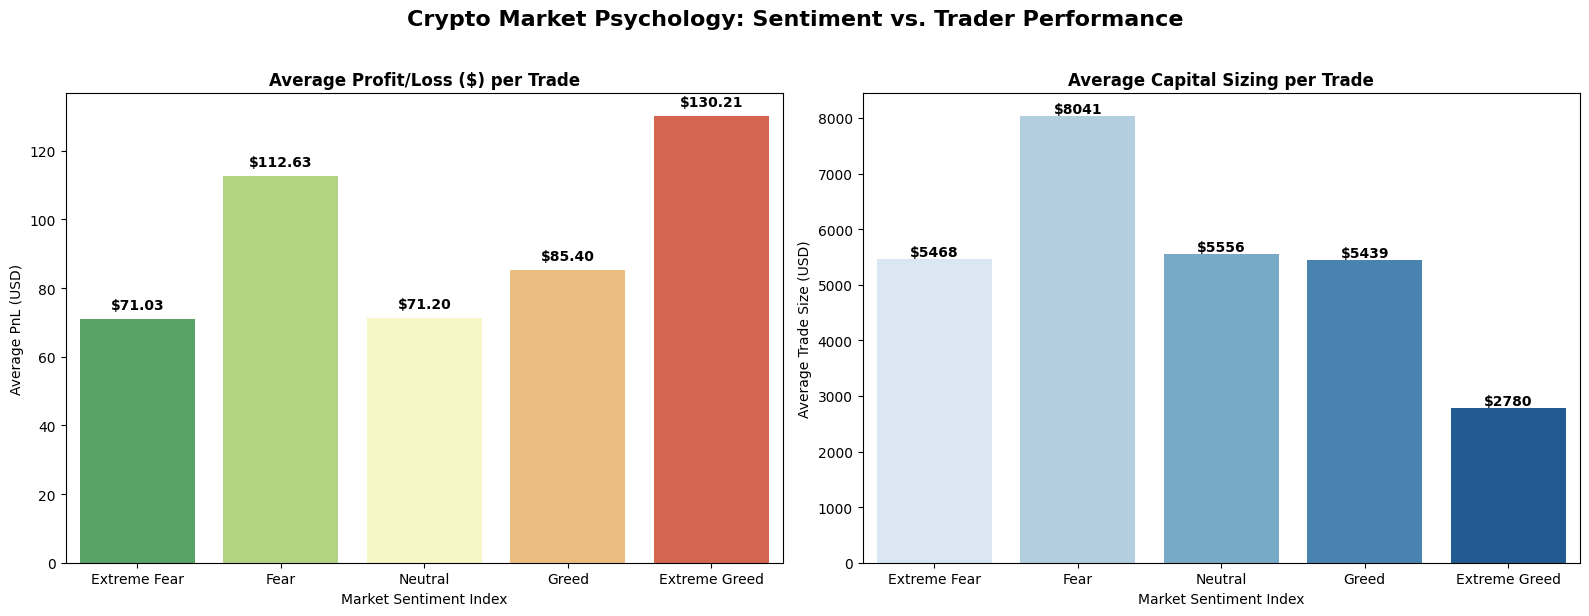

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

sentiment_analysis['classification'] = pd.Categorical(
    sentiment_analysis['classification'],
    categories=sentiment_order,
    ordered=True
)
sentiment_analysis = sentiment_analysis.sort_values('classification')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Crypto Market Psychology: Sentiment vs. Trader Performance', fontsize=16, fontweight='bold', y=1.02)

sns.barplot(
    data=sentiment_analysis,
    x='classification',
    y='Average_PnL ($)',
    ax=axes[0],
    palette='RdYlGn_r'
)
axes[0].set_title('Average Profit/Loss ($) per Trade', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Market Sentiment Index', fontsize=10)
axes[0].set_ylabel('Average PnL (USD)', fontsize=10)

for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height():.2f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, -15 if p.get_height() < 0 else 10),
                     textcoords='offset points', fontsize=10, fontweight='bold')

sns.barplot(
    data=sentiment_analysis,
    x='classification',
    y='Avg_Trade_Size_USD ($)',
    ax=axes[1],
    palette='Blues'
)
axes[1].set_title('Average Capital Sizing per Trade', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Market Sentiment Index', fontsize=10)
axes[1].set_ylabel('Average Trade Size (USD)', fontsize=10)

for p in axes[1].patches:
    axes[1].annotate(f"${p.get_height():.0f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 5),
                     textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
side_analysis = realized_trades.groupby(['classification', 'Side']).agg(
    Trade_Count=('Account', 'count'),
    Avg_PnL=('Closed PnL', 'mean'),
    Win_Rate=('is_win', 'mean')
).reset_index()

side_analysis['Win_Rate (%)'] = (side_analysis['Win_Rate'] * 100).round(2)
side_analysis['Avg_PnL ($)'] = side_analysis['Avg_PnL'].round(2)

print("=== LONG VS SHORT PERFORMANCE ACROSS CYCLES ===")
print(side_analysis.to_string(index=False))

=== LONG VS SHORT PERFORMANCE ACROSS CYCLES ===
classification Side  Trade_Count    Avg_PnL  Win_Rate  Win_Rate (%)  Avg_PnL ($)
  Extreme Fear  BUY         3123 119.450350  0.706052         70.61       119.45
  Extreme Fear SELL         7283  50.263189  0.786214         78.62        50.26
 Extreme Greed  BUY         6500  28.977039  0.859538         85.95        28.98
 Extreme Greed SELL        14353 176.048252  0.906222         90.62       176.05
          Fear  BUY         9230 209.650427  0.862514         86.25       209.65
          Fear SELL        20578  69.106910  0.877539         87.75        69.11
         Greed  BUY        11343  54.170553  0.689147         68.91        54.17
         Greed SELL        13833 111.015159  0.834309         83.43       111.02
       Neutral  BUY         5861  94.593942  0.776830         77.68        94.59
       Neutral SELL        12298  60.050869  0.846316         84.63        60.05
